In [16]:
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import h5py

In [17]:
ROOT = Path("/Users/nguyendang/Desktop/DS200.Q21/project_TransUNet/data/Synapse")

TRAIN_NPZ_DIR = ROOT / "train_npz"
TEST_H5_DIR   = ROOT / "test_vol_h5"

print("TRAIN_NPZ_DIR exists:", TRAIN_NPZ_DIR.exists())
print("TEST_H5_DIR exists  :", TEST_H5_DIR.exists())

npz_files = sorted(TRAIN_NPZ_DIR.glob("*.npz"))
h5_files  = sorted(TEST_H5_DIR.glob("*.npy.h5"))

print("train slices:", len(npz_files))
print("test volumes:", len(h5_files))

TRAIN_NPZ_DIR exists: True
TEST_H5_DIR exists  : True
train slices: 2211
test volumes: 12


In [18]:
ID2ORGAN = {
    0: "background",
    1: "spleen",
    2: "right kidney",
    3: "left kidney",
    4: "gallbladder",
    5: "liver",
    6: "stomach",
    7: "aorta",
    8: "pancreas",
}

LABEL_COLORS = {
    0: (0, 0, 0),
    1: (102, 204, 255),  # spleen
    2: (0, 255, 255),    # right kidney
    3: (255, 0, 0),      # left kidney
    4: (0, 255, 0),      # gallbladder
    5: (255, 0, 255),    # liver
    6: (220, 220, 220),  # stomach
    7: (0, 0, 255),      # aorta
    8: (255, 255, 0),    # pancreas
}

def normalize_ct(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

def label_to_rgb(lbl, color_map):
    h, w = lbl.shape
    rgb = np.zeros((h, w, 3), dtype=np.float32)
    for k, c in color_map.items():
        rgb[lbl == k] = np.array(c, dtype=np.float32) / 255.0
    return rgb

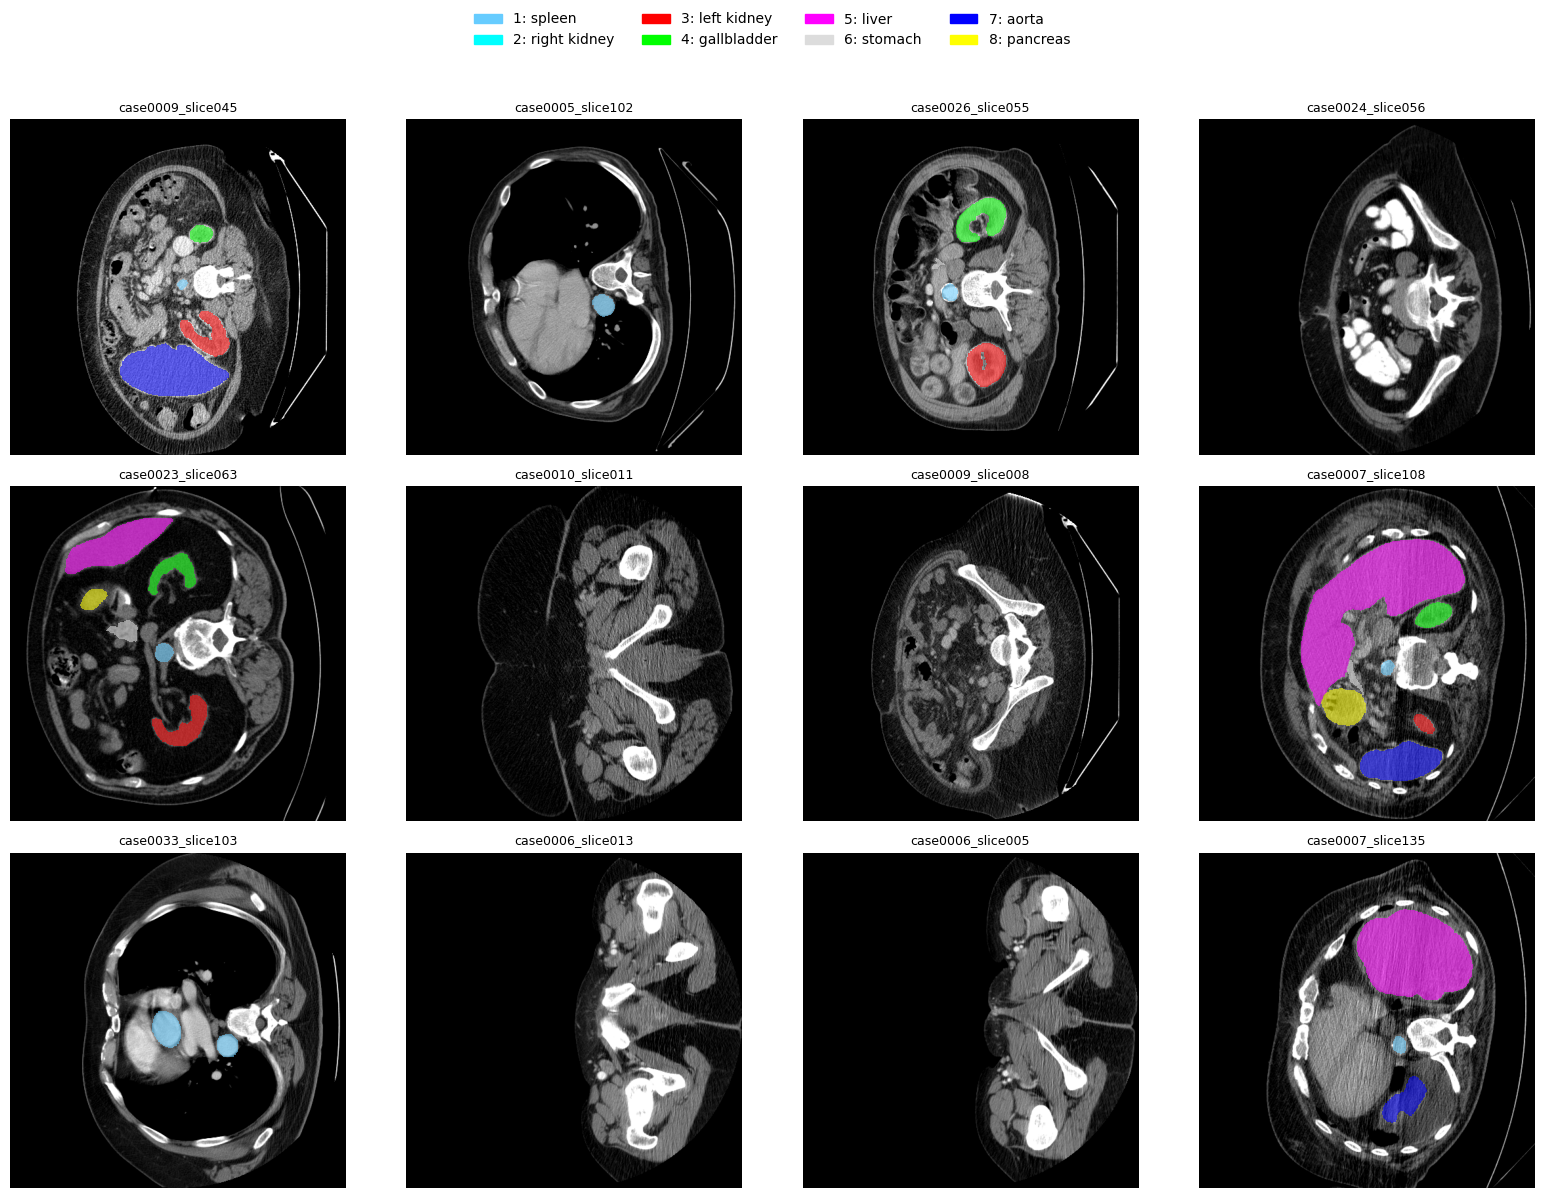

Saved: visualizations/synapse_train_overlay_grid.png


In [19]:
random.seed(42)
samples = random.sample(npz_files, 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, f in enumerate(samples):
    d = np.load(f)
    img = d["image"].astype(np.float32)
    lbl = d["label"].astype(np.int32)

    img_n = normalize_ct(img)
    rgb = label_to_rgb(lbl, LABEL_COLORS)

    axes[i].imshow(img_n, cmap="gray")
    axes[i].imshow(np.where((lbl > 0)[..., None], rgb, np.nan), alpha=0.55)
    axes[i].set_title(f.name.replace(".npz", ""), fontsize=9)
    axes[i].axis("off")

handles = [
    mpatches.Patch(color=np.array(v)/255.0, label=f"{k}: {ID2ORGAN[k]}")
    for k, v in LABEL_COLORS.items() if k != 0
]
fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/Users/nguyendang/Desktop/DS200.Q21/visualizations/synapse_train_overlay_grid.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved: visualizations/synapse_train_overlay_grid.png")

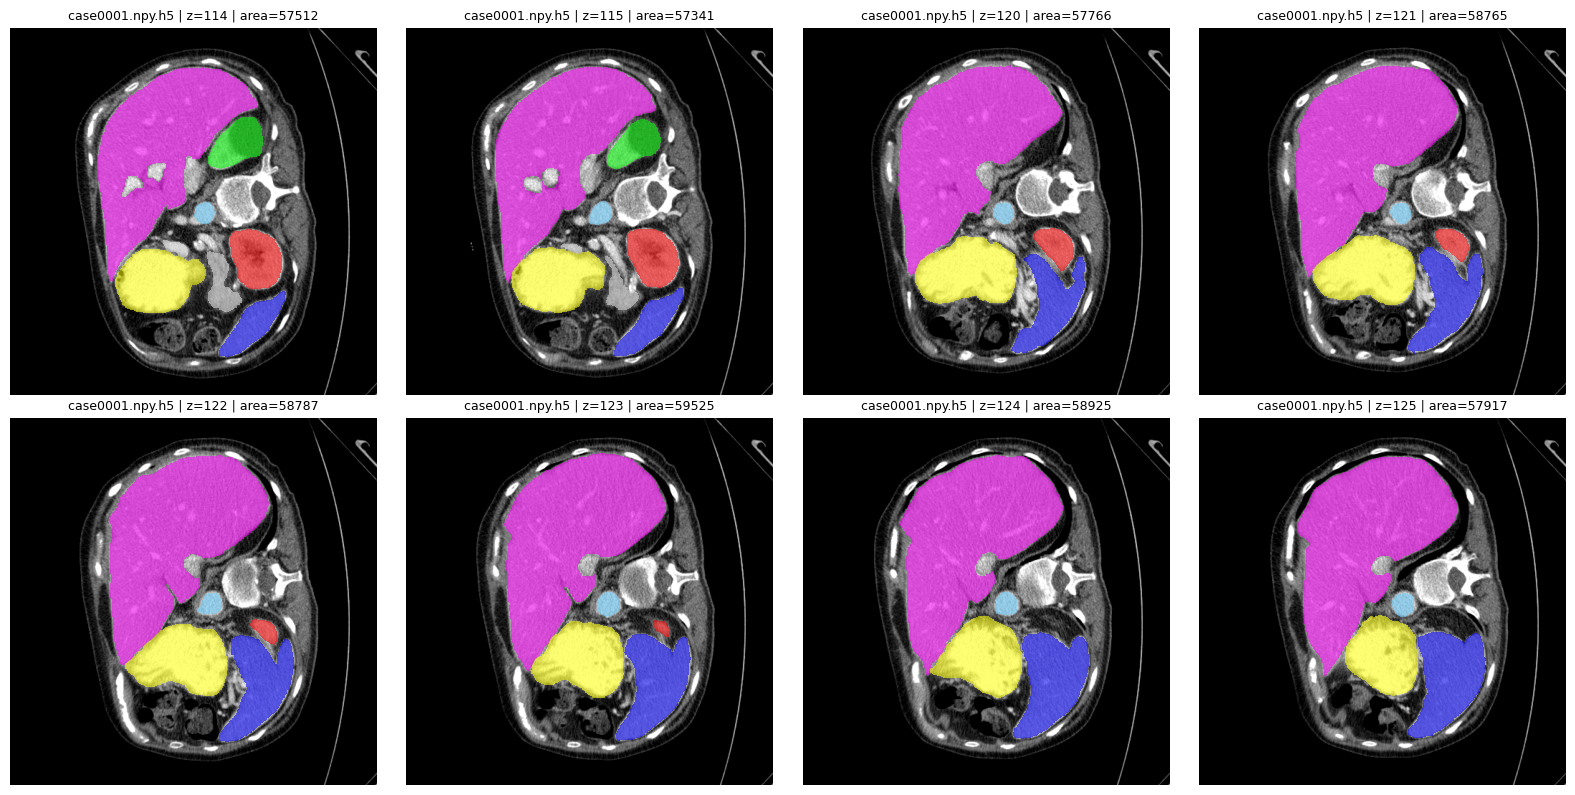

Saved: visualizations/synapse_test_volume_slices.png


In [20]:
case = h5_files[0]  # đổi sang h5_files[1], [2]... nếu muốn
with h5py.File(case, "r") as f:
    vol_img = f["image"][:]   # [D,H,W]
    vol_lbl = f["label"][:]   # [D,H,W]

k = 8
mask_area = (vol_lbl > 0).sum(axis=(1, 2))
z_list = np.argsort(mask_area)[-k:]
z_list = np.sort(z_list)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, z in enumerate(z_list):
    img = normalize_ct(vol_img[z])
    lbl = vol_lbl[z].astype(np.int32)
    rgb = label_to_rgb(lbl, LABEL_COLORS)

    axes[i].imshow(img, cmap="gray")
    axes[i].imshow(np.where((lbl > 0)[..., None], rgb, np.nan), alpha=0.55)
    axes[i].set_title(f"{case.name} | z={z} | area={mask_area[z]}", fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("/Users/nguyendang/Desktop/DS200.Q21/visualizations/synapse_test_volume_slices.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved: visualizations/synapse_test_volume_slices.png")

Class distribution:
0: background    pixels=554315625
1: spleen        pixels=922056
2: right kidney  pixels=245028
3: left kidney   pixels=1344662
4: gallbladder   pixels=1333973
5: liver         pixels=14192919
6: stomach       pixels=651861
7: aorta         pixels=3119429
8: pancreas      pixels=3474831


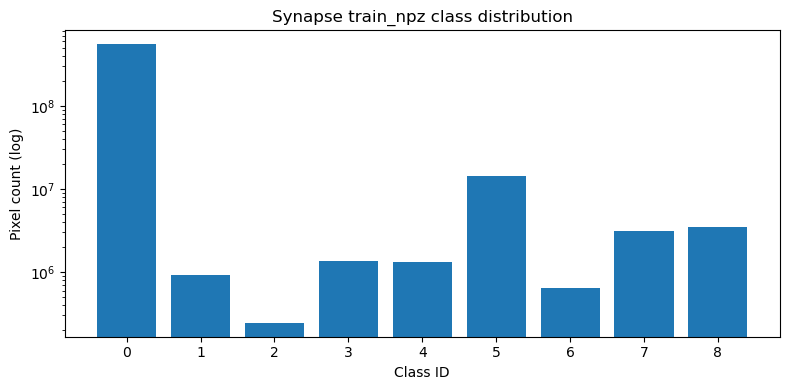

Saved: visualizations/synapse_class_distribution.png


In [21]:
num_classes = 9
pixel_counts = np.zeros(num_classes, dtype=np.int64)

for f in npz_files:
    lbl = np.load(f)["label"].astype(np.int32)
    pixel_counts += np.bincount(lbl.ravel(), minlength=num_classes)

print("Class distribution:")
for i in range(num_classes):
    print(f"{i}: {ID2ORGAN[i]:<13} pixels={pixel_counts[i]}")

plt.figure(figsize=(8,4))
plt.bar(range(num_classes), pixel_counts)
plt.yscale("log")
plt.xticks(range(num_classes), [f"{i}" for i in range(num_classes)])
plt.xlabel("Class ID")
plt.ylabel("Pixel count (log)")
plt.title("Synapse train_npz class distribution")
plt.tight_layout()
plt.savefig("/Users/nguyendang/Desktop/DS200.Q21/visualizations/synapse_class_distribution.png", dpi=220)
plt.show()

print("Saved: visualizations/synapse_class_distribution.png")